# What the failure actually looks like: hallucination prevalence per model size

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AgrfhyL/audio_model_initial_testing/blob/main/Colab_Hallucinations.ipynb)

Corpus WER says late-placed utterances degrade. `delta_m` says *which* utterances carry the
damage. Neither says **what the damage is**. The claim that the effect is "tail-driven by looping
hallucinations" has so far rested on reading a handful of transcripts by eye — a plausible story,
not a measurement.

This notebook counts them. For every hypothesis experiment A produced it asks two questions of the
text — is it far longer than the reference, and does it repeat itself — and reports the share of
utterances that fail either test, per model, per condition.

**Nothing is decoded.** No GPU, no TIMIT audio, no checkpoint download, no `whisper.decode()`.
The inputs are two files experiment A already wrote to Drive, and the whole notebook runs on a CPU
runtime in about a minute.

### Why this is a separate notebook rather than a section of the delta sweep

`Colab_DeltaSweep.ipynb` costs ~14 min of corpus verification and ~2 min of GPU sweep before it
reaches its first statistic, and it needs a private TIMIT copy on Drive to do it. Classifying text
that has already been written needs neither. Keeping it separate is what makes the classification
cheap to re-run when the definition of "hallucination" is argued with — which it will be, because
unlike WER it is a judgement call rather than an arithmetic one.

## 1. Inputs

Two files, both under `MyDrive/NAACL/`, both written by `Colab_DeltaSweep.ipynb`:

| file | rows | what this notebook takes from it |
|---|---|---|
| `delta_results_full.csv` | 20 000 | `text` — the hypothesis, one row per (model, path, offset, arm) |
| `delta_per_utterance.csv` | 5 000 | `n_ref_words` and the four per-utterance WERs |

Reading **both** is a deliberate choice. The length test needs the reference *length*, and taking
it from the numbers-only file rather than from TIMIT `.TXT` means this notebook needs no TIMIT copy
at all — the one input that would otherwise force it onto a Drive with licensed audio on it. The
join also carries the four WERs across, which is what lets section 7 cross-tabulate the text-based
verdict against the `WER > 1` proxy and say how far a numbers-only analysis would have got.

`delta_results_full.csv` is gitignored because it carries hypothesis text. This notebook consumes
that text and emits only counts, so — unlike experiments A, B and C — it has **no** text-bearing
output and needs no Drive-only companion file.

In [24]:
# openai-whisper is installed for exactly one import: EnglishTextNormalizer. The WERs being
# cross-tabulated in section 7 were computed on normalized text, so tokenizing raw text here
# would make the two columns disagree over punctuation rather than over hallucination.
!pip -q install openai-whisper

import collections, csv, hashlib, json, math, os, platform, sys, time
import numpy as np

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/NAACL"
FULL_CSV   = os.path.join(DRIVE_ROOT, "delta_results_full.csv")    # has hypotheses
SAFE_IN    = os.path.join(DRIVE_ROOT, "delta_per_utterance.csv")   # numbers only
OUT_CSV    = os.path.join(DRIVE_ROOT, "halluc_per_utterance.csv")  # numbers only, git-safe
PROV_JSON  = os.path.join(DRIVE_ROOT, "halluc_provenance.json")

MODELS = ["tiny", "base", "small", "medium", "large-v3"]
PARAMS = {"tiny": "37.2M", "base": "71.8M", "small": "240.6M",
          "medium": "762.3M", "large-v3": "1541.6M"}
CONDS  = [(5, "on"), (5, "off"), (25, "on"), (25, "off")]
HEAD   = (25, "on")        # the condition the positional penalty lives in

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load, digest, and check the grid

The two inputs are hashed so a classification can be tied to exactly the sweep it read; if the
delta sweep is ever re-run, the digest moves and stale numbers are visible rather than silent.

Three structural checks before anything is counted, and one that is easy to skip and expensive to
get wrong:

**`decode()` strips timestamp tokens from `text` — verify it rather than assume it.**
`Tokenizer.decode` drops every id at or above `<|endoftext|>`, and the timestamp block sits above
it, so `<|25.00|>` should never appear in the `text` column even in the timestamps-on arm. If it
did, the markers would count as words: they would inflate the length ratio and, since a transcript
alternates text and timestamps, hand the repeat detector a spurious periodic structure. The check
costs one substring scan over 20 000 rows.

In [25]:
def sha256_file(path, buf=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()

for p in (FULL_CSV, SAFE_IN):
    assert os.path.exists(p), f"missing input: {p}\nrun Colab_DeltaSweep.ipynb first"

INPUT_DIGESTS = {os.path.basename(p): sha256_file(p) for p in (FULL_CSV, SAFE_IN)}

full = list(csv.DictReader(open(FULL_CSV, newline="")))
safe = list(csv.DictReader(open(SAFE_IN,  newline="")))

# --- grid completeness ---------------------------------------------------------------
assert len(safe) == len(MODELS) * 1000, len(safe)
cells = collections.Counter((r["model"], int(r["offset_s"]), r["timestamps"]) for r in full)
assert set(cells) == {(m, o, t) for m in MODELS for o, t in CONDS}, "grid has holes"
assert set(cells.values()) == {1000}, sorted(set(cells.values()))
assert len(full) == len(MODELS) * len(CONDS) * 1000, len(full)
assert len({(r["model"], r["path"], r["offset_s"], r["timestamps"]) for r in full}) == len(full)

# --- the join: reference length and the four WERs, keyed by (model, path) -------------
META = {(r["model"], r["path"]): r for r in safe}
missing = [r for r in full if (r["model"], r["path"]) not in META]
assert not missing, f"{len(missing)} decode rows have no row in {os.path.basename(SAFE_IN)}"

# --- special tokens must not have leaked into `text` ----------------------------------
leaked = sum("<|" in r["text"] for r in full)
assert leaked == 0, f"{leaked} rows carry special tokens in text; the detector would misread them"

print(f"{len(full)} hypotheses | {len(MODELS)} models x {len(CONDS)} conditions x 1000 clips")
print(f"joined to {len(safe)} per-utterance rows; no special tokens in any hypothesis\n")
for k, v in INPUT_DIGESTS.items():
    print(f"  {k:<26} sha256 {v[:16]}...")

20000 hypotheses | 5 models x 4 conditions x 1000 clips
joined to 5000 per-utterance rows; no special tokens in any hypothesis

  delta_results_full.csv     sha256 6c35286a943503bf...
  delta_per_utterance.csv    sha256 94efd4fa74b34613...


## 3. What counts as a hallucination

WER cannot answer this on its own. A hypothesis with `WER = 1.4` might be forty words of looping
garbage against a ten-word reference, or it might be ten words that are simply wrong plus four
spurious ones. Those are different failures and only the first is a hallucination. So the test is
applied to the text.

Two components, each reported separately so the definition stays auditable:

- **runaway** — `n_hyp >= 2 x n_ref`. The model emitted at least twice the reference length.
- **loop** — some n-gram, `n <= 5`, repeats at least 3 times back to back. This is the documented
  Whisper failure mode: `the the the`, or `thank you. thank you. thank you.`

An utterance is hallucinated if **either** fires. Neither component contains the other: a short
utterance can loop without doubling in length, and a model can run away with novel text rather
than repeated text. Section 6 sweeps both thresholds, so the headline number is not silently
resting on `2.0` and `3`.

### Two implementation details that change the counts

**Normalize before tokenizing.** `EnglishTextNormalizer` is what produced the WERs this is compared
against. It also strips punctuation, which matters more than it sounds: unnormalized,
`Thank you. Thank you. Thank you.` and `thank you thank you thank you` are different token
sequences, and only one of them is a clean 3-repetition of a bigram.

**Step start positions by one, but step the repeat count by `n`.** A scan that advances by one *and*
counts overlapping matches scores `a b a b a b` as four repetitions rather than three, because
`[b a]` at position 1 also matches `[b a]` at position 3. Advancing the outer loop by one is still
necessary — a loop can begin at any phase, and `x a b a b a b y` must be found — so the two loops
step differently. `max_repeat_run` is unit-tested against exactly these cases below, because every
count in this notebook rests on it.

In [26]:
from whisper.normalizers import EnglishTextNormalizer

normalizer = EnglishTextNormalizer()

LEN_RATIO = 2.0     # hypothesis at least this many times the reference length
MIN_REPS  = 3       # an n-gram repeated at least this many times back to back
MAX_N     = 5       # longest n-gram considered
RUN_CAP   = 64      # stop counting past here; beyond it the exact value carries no information


def max_repeat_run(words, max_n=MAX_N, cap=RUN_CAP):
    """Longest chain of consecutive repetitions of any 1..max_n-gram. 1 = nothing repeats.

    Outer loop steps by 1 so a loop is found at whatever phase it starts; the inner count
    steps by n so overlapping shifts are not counted as extra repetitions.
    """
    best, L = 1, len(words)
    for n in range(1, max_n + 1):
        for i in range(0, L - n + 1):
            k = 1
            while i + (k + 1) * n <= L and words[i + k * n: i + (k + 1) * n] == words[i: i + n]:
                k += 1
            if k > best:
                best = k
                if best >= cap:
                    return best
    return best


assert max_repeat_run("a b c".split()) == 1                 # nothing repeats
assert max_repeat_run("a a a a".split()) == 4               # unigram x4
assert max_repeat_run("a b c a b c".split()) == 2           # trigram x2
assert max_repeat_run("x a b a b a b y".split()) == 3       # phase offset: 3, not the 4 an
assert max_repeat_run([]) == 1                              #   overlapping scan would give
print(f"detector: n_hyp >= {LEN_RATIO:g} x n_ref   OR   an n-gram (n <= {MAX_N}) "
      f"repeated >= {MIN_REPS}x consecutively")

detector: n_hyp >= 2 x n_ref   OR   an n-gram (n <= 5) repeated >= 3x consecutively


## 4. Classify

One pass over the 20 000 hypotheses. Both raw measurements are kept — `len_ratio` and `max_run` —
not just the boolean verdict, which is what lets section 6 re-threshold and any later analysis
re-define "hallucination" without ever touching the text file again.

In [27]:
t0 = time.time()
per_utt = []
for r in full:
    m, p, ts = r["model"], r["path"], r["timestamps"]
    off  = int(r["offset_s"])
    meta = META[(m, p)]

    hyp   = normalizer(r["text"]).split()
    n_ref = int(meta["n_ref_words"])
    n_hyp = len(hyp)
    ratio = n_hyp / n_ref
    run   = max_repeat_run(hyp)

    runaway, loop = ratio >= LEN_RATIO, run >= MIN_REPS
    per_utt.append({
        "model": m, "path": p, "speaker": meta["speaker"], "region": meta["region"],
        "offset_s": off, "timestamps": ts,
        "n_ref_words": n_ref, "n_hyp_words": n_hyp,
        "len_ratio": f"{ratio:.4f}", "max_run": run,
        "wer": meta[f"wer_{ts}_{off}"],           # wer_on_25, wer_off_5, ...
        "avg_logprob": f"{float(r['avg_logprob']):.6f}",
        "runaway": int(runaway), "loop": int(loop), "halluc": int(runaway or loop),
    })

BY = collections.defaultdict(list)
for r in per_utt:
    BY[(r["model"], r["offset_s"], r["timestamps"])].append(r)

print(f"classified {len(per_utt)} hypotheses in {time.time() - t0:.0f}s")

classified 20000 hypotheses in 10s


## 5. Prevalence

Rates are proportions out of 1000, so the interval is a **Wilson score** interval — the normal
approximation misbehaves at the small counts expected for `medium` and `large-v3` and can put the
lower bound below zero, which Wilson cannot.

A **speaker-clustered** bootstrap is printed alongside for the headline condition. Utterances from
one speaker are not independent — 168 speakers contribute 5–6 clips each — and Wilson assumes they
are. Resampling whole speakers relaxes that assumption; the delta sweep found the two agree closely
on `delta_m`, and printing both here keeps the assumption visible rather than buried.

In [28]:
def wilson(k, n, z=1.959963985):
    if n == 0:
        return float("nan"), 0.0, 1.0
    p, d = k / n, 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, c - h), min(1.0, c + h)


def cluster_ci(flags, speakers, n_boot=10000, alpha=0.05, seed=0):
    """Percentile bootstrap resampling whole speakers rather than utterances."""
    f, g = np.asarray(flags, float), np.asarray(speakers)
    pool = [np.flatnonzero(g == u) for u in np.unique(g)]
    K, rng = len(pool), np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        boots[b] = f[np.concatenate([pool[j] for j in rng.integers(0, K, K)])].mean()
    return float(np.quantile(boots, alpha / 2)), float(np.quantile(boots, 1 - alpha / 2))


SUMMARY = {}
print("hallucinated utterances, % of 1000 per cell   [Wilson 95% CI]\n")
hdr = f"{'model':>9} {'params':>8} " + " ".join(f"{f'{o} s / ts {t}':>21}" for o, t in CONDS)
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    out = []
    for o, t in CONDS:
        rs = BY[(m, o, t)]
        k = sum(r["halluc"] for r in rs)
        p, lo, hi = wilson(k, len(rs))
        SUMMARY[f"{m}|{o}|{t}"] = {"n": len(rs), "k": k, "rate": p,
                                   "wilson_lo": lo, "wilson_hi": hi}
        out.append(f"{100*p:5.1f} [{100*lo:4.1f},{100*hi:4.1f}]")
    print(f"{m:>9} {PARAMS[m]:>8} " + " ".join(f"{c:>21}" for c in out))

print(f"\ncomponents at {HEAD[0]} s / timestamps {HEAD[1]}  (n = 1000)")
hdr = (f"{'model':>9} {'runaway':>8} {'loop':>6} {'both':>6} {'either':>7}"
       f" {'median max_run':>15} {'median len_ratio':>17}")
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    rs = BY[(m, *HEAD)]
    hall = [r for r in rs if r["halluc"]]
    print(f"{m:>9} {sum(r['runaway'] for r in rs):>8} {sum(r['loop'] for r in rs):>6}"
          f" {sum(r['runaway'] and r['loop'] for r in rs):>6}"
          f" {sum(r['halluc'] for r in rs):>7}"
          f" {(np.median([r['max_run'] for r in hall]) if hall else float('nan')):>15.1f}"
          f" {(np.median([float(r['len_ratio']) for r in hall]) if hall else float('nan')):>17.1f}")

print(f"\nspeaker-clustered cross-check at {HEAD[0]} s / ts {HEAD[1]} "
      f"(resamples 168 speakers, not utterances)")
for m in MODELS:
    rs = BY[(m, *HEAD)]
    s = SUMMARY[f"{m}|{HEAD[0]}|{HEAD[1]}"]
    lo, hi = cluster_ci([r["halluc"] for r in rs], [r["speaker"] for r in rs])
    s["cluster_lo"], s["cluster_hi"] = lo, hi
    print(f"{m:>10}  wilson [{100*s['wilson_lo']:5.2f}, {100*s['wilson_hi']:5.2f}]"
          f"   speaker [{100*lo:5.2f}, {100*hi:5.2f}]")

hallucinated utterances, % of 1000 per cell   [Wilson 95% CI]

    model   params           5 s / ts on          5 s / ts off          25 s / ts on         25 s / ts off
----------------------------------------------------------------------------------------------------------
     tiny    37.2M       0.3 [ 0.1, 0.9]       0.1 [ 0.0, 0.6]       9.9 [ 8.2,11.9]       0.0 [ 0.0, 0.4]
     base    71.8M       0.2 [ 0.1, 0.7]       0.0 [ 0.0, 0.4]       2.3 [ 1.5, 3.4]       0.1 [ 0.0, 0.6]
    small   240.6M       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.8 [ 0.4, 1.6]       0.0 [ 0.0, 0.4]
   medium   762.3M       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]
 large-v3  1541.6M       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]

components at 25 s / timestamps on  (n = 1000)
    model  runaway   loop   both  either  median max_run  median len_ratio
-----------------------------------------------------------------

## 6. Sensitivity to the thresholds

`2.0` and `3` are defensible but arbitrary, and a headline that only survives at one setting is not
a finding. Both are swept over the stored `len_ratio` and `max_run` columns — no text is re-read,
because the raw measurements were kept in section 4.

What matters is not whether the absolute rate moves (it will) but whether the **ordering across
model size** survives. That ordering is the claim; the level is a definition.

In [29]:
RATIOS, REPS = [1.5, 2.0, 3.0], [2, 3, 4]

print(f"hallucination rate (%) at {HEAD[0]} s / timestamps {HEAD[1]}, over the threshold grid\n")
hdr = (f"{'len_ratio':>9} {'min_reps':>9} " + " ".join(f"{m:>9}" for m in MODELS)
       + "   monotone in size?")
print(hdr + "\n" + "-" * len(hdr))
for lr in RATIOS:
    for mr in REPS:
        rates = []
        for m in MODELS:
            rs = BY[(m, *HEAD)]
            k = sum(float(r["len_ratio"]) >= lr or r["max_run"] >= mr for r in rs)
            rates.append(100 * k / len(rs))
        mono = all(a >= b - 1e-9 for a, b in zip(rates, rates[1:]))
        print(f"{lr:>9.1f} {mr:>9d} " + " ".join(f"{v:>9.1f}" for v in rates)
              + f"   {'yes' if mono else 'no'}")

hallucination rate (%) at 25 s / timestamps on, over the threshold grid

len_ratio  min_reps      tiny      base     small    medium  large-v3   monotone in size?
-----------------------------------------------------------------------------------------
      1.5         2      12.3       3.0       1.2       0.3       0.5   no
      1.5         3      12.1       2.9       1.0       0.1       0.2   no
      1.5         4      12.1       2.9       1.0       0.1       0.2   no
      2.0         2      10.1       2.4       1.0       0.2       0.3   no
      2.0         3       9.9       2.3       0.8       0.0       0.0   yes
      2.0         4       9.9       2.3       0.8       0.0       0.0   yes
      3.0         2      10.0       2.3       0.9       0.2       0.3   no
      3.0         3       9.8       2.2       0.7       0.0       0.0   yes
      3.0         4       9.8       2.2       0.7       0.0       0.0   yes


## 7. How far would the numbers-only file have got?

`delta_per_utterance.csv` is committable; `delta_results_full.csv` is not. So it is worth knowing
what a purely numeric analysis could have concluded, and `WER > 1` is the natural candidate — not
an arbitrary cut, but exactly the point where `I > C`, more inserted words than correctly
recognized ones, since `WER = (S+D+I)/N` and `N = S+D+C`.

The cross-tabulation below is the answer. `text only` counts hallucinations the proxy misses;
`proxy only` counts utterances the proxy over-flags — short references scored badly wrong without
any runaway or repetition.

In [30]:
hdr = (f"{'model':>9} {'condition':>12} {'text':>6} {'WER>1':>7} {'both':>6}"
       f" {'text only':>10} {'proxy only':>11} {'recall':>7}")
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    for o, t in CONDS:
        rs = BY[(m, o, t)]
        tx = sum(r["halluc"] for r in rs)
        px = sum(float(r["wer"]) > 1.0 for r in rs)
        bo = sum(r["halluc"] and float(r["wer"]) > 1.0 for r in rs)
        rec = f"{bo / tx:.2f}" if tx else "  -"
        print(f"{m:>9} {f'{o} s / ts {t}':>12} {tx:>6} {px:>7} {bo:>6}"
              f" {tx - bo:>10} {px - bo:>11} {rec:>7}")

    model    condition   text   WER>1   both  text only  proxy only  recall
---------------------------------------------------------------------------
     tiny  5 s / ts on      3       8      3          0           5    1.00
     tiny 5 s / ts off      1       6      1          0           5    1.00
     tiny 25 s / ts on     99     121     99          0          22    1.00
     tiny 25 s / ts off      0       5      0          0           5       -
     base  5 s / ts on      2       5      2          0           3    1.00
     base 5 s / ts off      0       2      0          0           2       -
     base 25 s / ts on     23      27     22          1           5    0.96
     base 25 s / ts off      1       2      1          0           1    1.00
    small  5 s / ts on      0       2      0          0           2       -
    small 5 s / ts off      0       1      0          0           1       -
    small 25 s / ts on      8      12      8          0           4    1.00
    small 

## 8. Would `transcribe()`'s own confidence filter have caught them?

`decode()` reports `avg_logprob` but acts on nothing. `transcribe()` does act: its fallback ladder
flags a window whose `avg_logprob` falls below `logprob_threshold = -1.0`. That threshold is
Whisper's own published notion of "this decode went wrong", so it is the fair reference point for
whether these failures are detectable without a reference transcript.

The catch, documented in `Transcribe_Offset.ipynb`: with a scalar `temperature=0.0` the ladder has
no second temperature to escalate to, so the threshold flags the window and returns it anyway. The
number below is therefore an upper bound on what a confidence filter could have caught, not a
description of what stock `transcribe()` actually suppresses.

In [31]:
print(f"avg_logprob at {HEAD[0]} s / timestamps {HEAD[1]}\n")
hdr = (f"{'model':>9} {'mean (halluc)':>14} {'mean (clean)':>13}"
       f" {'below -1.0':>11} {'of halluc':>10} {'false alarms':>13}")
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    rs = BY[(m, *HEAD)]
    h = [float(r["avg_logprob"]) for r in rs if r["halluc"]]
    c = [float(r["avg_logprob"]) for r in rs if not r["halluc"]]
    caught = sum(v < -1.0 for v in h)
    false  = sum(v < -1.0 for v in c)
    print(f"{m:>9} {(np.mean(h) if h else float('nan')):>14.3f}"
          f" {(np.mean(c) if c else float('nan')):>13.3f}"
          f" {caught:>11} {(f'{caught}/{len(h)}' if h else '-'):>10} {false:>13}")

avg_logprob at 25 s / timestamps on

    model  mean (halluc)  mean (clean)  below -1.0  of halluc  false alarms
---------------------------------------------------------------------------
     tiny         -0.427        -0.716           3       3/99           103
     base         -0.435        -0.653           0       0/23            59
    small         -0.949        -0.492           3        3/8            17
   medium            nan        -0.368           0          -             1
 large-v3            nan        -0.272           0          -             2


## 9. Write the results

One output file, and it is numbers only. The guard is the same one experiments A and C use: no
forbidden column name, and no value containing a space anywhere outside the identifier columns —
which is what a leaked transcript would look like.

There is no Drive-only companion this time. This notebook *consumes* hypothesis text and emits
counts, so `halluc_per_utterance.csv` is safe to commit as written, and it keeps `len_ratio` and
`max_run` so the definition can be revisited without the text file.

In [32]:
SAFE_FIELDS = ["model", "path", "speaker", "region", "offset_s", "timestamps",
               "n_ref_words", "n_hyp_words", "len_ratio", "max_run", "wer",
               "avg_logprob", "runaway", "loop", "halluc"]
FORBIDDEN   = {"text", "reference", "hypothesis", "ref", "hyp", "transcript"}
IDENT       = {"model", "path", "speaker", "region", "timestamps"}

assert not (set(SAFE_FIELDS) & FORBIDDEN), "a text-bearing column leaked into SAFE_FIELDS"
assert set(per_utt[0]) == set(SAFE_FIELDS), set(per_utt[0]) ^ set(SAFE_FIELDS)
for row in per_utt:
    for k, v in row.items():
        assert k in IDENT or " " not in str(v), (k, v)

with open(OUT_CSV, "w", newline="") as f:
    wr = csv.DictWriter(f, fieldnames=SAFE_FIELDS)
    wr.writeheader()
    wr.writerows(per_utt)

import whisper
PROVENANCE = {
    "experiment": "hallucination prevalence per model size, from experiment A's hypotheses",
    "derived_from": {"inputs": INPUT_DIGESTS,
                     "note": "no decoding; classification of stored hypotheses only"},
    "definition": {"halluc": "runaway OR loop",
                   "runaway": f"n_hyp >= {LEN_RATIO} * n_ref",
                   "loop": f"some n-gram, n <= {MAX_N}, repeated >= {MIN_REPS}x consecutively",
                   "normalizer": "whisper.normalizers.EnglishTextNormalizer",
                   "max_run_cap": RUN_CAP},
    "packages": {"python": platform.python_version(), "openai-whisper": whisper.__version__,
                 "numpy": np.__version__},
    "grid": {"models": MODELS, "conditions": [f"{o}s/ts-{t}" for o, t in CONDS],
             "clips_per_cell": 1000, "hypotheses": len(per_utt)},
    "summary": SUMMARY,
    "outputs": {"halluc_per_utterance.csv": {"rows": len(per_utt), "fields": SAFE_FIELDS,
                                             "git_safe": True}},
}
with open(PROV_JSON, "w") as f:
    json.dump(PROVENANCE, f, indent=1)

print(f"per-utterance -> {OUT_CSV}   ({len(per_utt)} rows, numbers only; safe to commit)")
print(f"provenance    -> {PROV_JSON}")
print("\nchecked: no text-bearing column, no free-text value in the git-safe file")

per-utterance -> /content/drive/MyDrive/NAACL/halluc_per_utterance.csv   (20000 rows, numbers only; safe to commit)
provenance    -> /content/drive/MyDrive/NAACL/halluc_provenance.json

checked: no text-bearing column, no free-text value in the git-safe file


## 10. Figure

PNG at 160 dpi for the notebook, as every other experiment writes; `Figures.ipynb` is where these
become vector PDF at ACL column width. Two panels so the arms cannot be conflated — the whole point
is that the timestamps-off arm stays flat while the timestamps-on arm does not.

wrote halluc_rate.png (+ a copy on Drive)


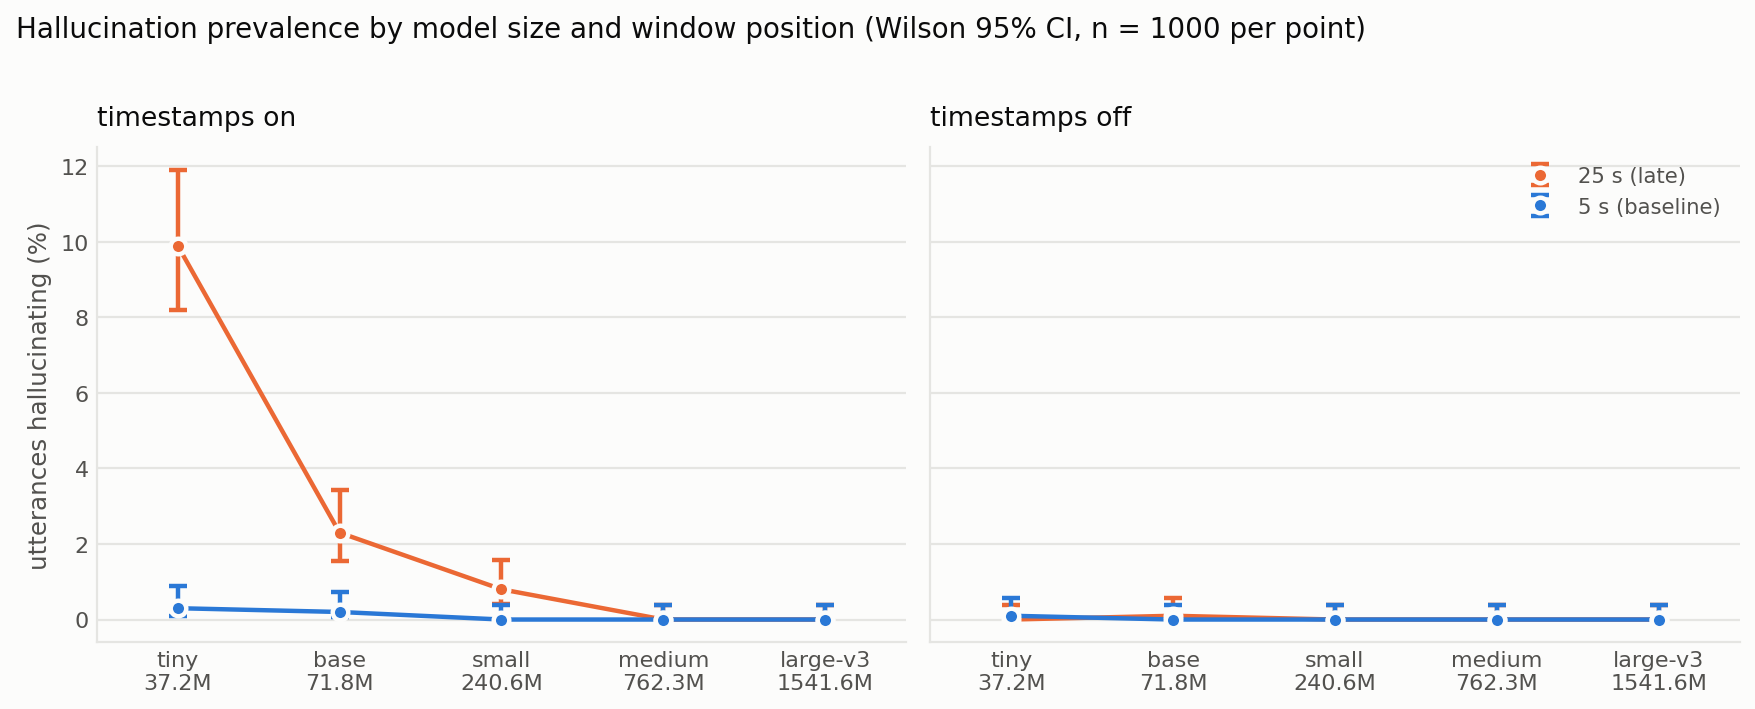

In [33]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e5e2"
C_LATE, C_EARLY = "#eb6834", "#2a78d6"

x = np.arange(len(MODELS))
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3), dpi=160, sharey=True)
fig.patch.set_facecolor(SURFACE)

for ax, arm in zip(axes, ("on", "off")):
    ax.set_facecolor(SURFACE)
    ax.grid(True, axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for off, colour, lab in ((25, C_LATE, "25 s (late)"), (5, C_EARLY, "5 s (baseline)")):
        s   = [SUMMARY[f"{m}|{off}|{arm}"] for m in MODELS]
        mid = [100 * v["rate"] for v in s]
        err = [[100 * (v["rate"] - v["wilson_lo"]) for v in s],
               [100 * (v["wilson_hi"] - v["rate"]) for v in s]]
        ax.errorbar(x, mid, yerr=err, fmt="o", color=colour, markersize=7, linewidth=2,
                    markeredgecolor=SURFACE, markeredgewidth=2, capsize=4, zorder=3, label=lab)
        ax.plot(x, mid, color=colour, linewidth=2, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{m}\n{PARAMS[m]}" for m in MODELS])
    ax.set_xlim(-0.5, len(MODELS) - 0.5)
    ax.set_title(f"timestamps {arm}", fontsize=12, color=INK, pad=10, loc="left")
    ax.tick_params(colors=INK2, labelsize=10, length=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRID); ax.spines[sp].set_linewidth(1)

axes[0].set_ylabel("utterances hallucinating (%)", fontsize=11, color=INK2)
leg = axes[1].legend(frameon=False, fontsize=9.5, loc="upper right")
for t in leg.get_texts():
    t.set_color(INK2)
fig.suptitle("Hallucination prevalence by model size and window position "
             "(Wilson 95% CI, n = 1000 per point)",
             fontsize=12.5, color=INK, x=0.007, ha="left", y=1.02)
fig.tight_layout()
fig.savefig("halluc_rate.png", bbox_inches="tight", facecolor=SURFACE)
fig.savefig(os.path.join(DRIVE_ROOT, "halluc_rate.png"), bbox_inches="tight", facecolor=SURFACE)
print("wrote halluc_rate.png (+ a copy on Drive)")
plt.show()

## 11. Standalone reload

No GPU, no TIMIT, no Drive-only file, and no earlier cell in this notebook. It reads the committed
`halluc_per_utterance.csv` and rebuilds the headline table, which proves both that the write
reached Drive rather than sitting in a FUSE buffer and that the git-safe file alone carries enough
to reproduce every number above.

In [34]:
import csv, collections, math, os

PATH = "/content/drive/MyDrive/NAACL/halluc_per_utterance.csv"   # or a local download
rows = list(csv.DictReader(open(PATH, newline="")))

MODELS_ = ["tiny", "base", "small", "medium", "large-v3"]
CONDS_  = [(5, "on"), (5, "off"), (25, "on"), (25, "off")]
by = collections.defaultdict(list)
for r in rows:
    by[(r["model"], int(r["offset_s"]), r["timestamps"])].append(r)


def wilson_(k, n, z=1.959963985):
    p, d = k / n, 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, c - h), min(1.0, c + h)


print(f"reloaded {len(rows)} rows from {os.path.basename(PATH)}\n")
print(f"{'model':>9} " + " ".join(f"{f'{o} s / ts {t}':>21}" for o, t in CONDS_))
print("-" * 96)
for m in MODELS_:
    out = []
    for o, t in CONDS_:
        rs = by[(m, o, t)]
        p, lo, hi = wilson_(sum(int(r["halluc"]) for r in rs), len(rs))
        out.append(f"{100*p:5.1f} [{100*lo:4.1f},{100*hi:4.1f}]")
    print(f"{m:>9} " + " ".join(f"{c:>21}" for c in out))

# re-thresholding needs only this file: len_ratio and max_run were kept
alt = {m: 100 * np.mean([float(r["len_ratio"]) >= 3.0 or int(r["max_run"]) >= 4
                         for r in by[(m, 25, "on")]]) for m in MODELS_}
print("\nstricter definition (ratio >= 3, reps >= 4) at 25 s / ts on:")
print("  " + "  ".join(f"{m} {alt[m]:.1f}%" for m in MODELS_))

reloaded 20000 rows from halluc_per_utterance.csv

    model           5 s / ts on          5 s / ts off          25 s / ts on         25 s / ts off
------------------------------------------------------------------------------------------------
     tiny       0.3 [ 0.1, 0.9]       0.1 [ 0.0, 0.6]       9.9 [ 8.2,11.9]       0.0 [ 0.0, 0.4]
     base       0.2 [ 0.1, 0.7]       0.0 [ 0.0, 0.4]       2.3 [ 1.5, 3.4]       0.1 [ 0.0, 0.6]
    small       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.8 [ 0.4, 1.6]       0.0 [ 0.0, 0.4]
   medium       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]
 large-v3       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]       0.0 [ 0.0, 0.4]

stricter definition (ratio >= 3, reps >= 4) at 25 s / ts on:
  tiny 9.8%  base 2.2%  small 0.7%  medium 0.0%  large-v3 0.0%
